# Brain Tumor MRI: 4 Class Classification


##### Imports


In [ ]:
import os
import re
import glob
import shutil
import random
import warnings
from collections import defaultdict
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
import cv2                
from PIL import Image
import imagehash
import albumentations as A
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve)
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess

print("TensorFlow version:", tf.__version__)
print("GPU available    :", len(tf.config.list_physical_devices("GPU")) > 0)


TensorFlow version: 2.21.0
GPU available    : True


#### Loading the dataset

In [ ]:
DATASET_DIR = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset" 
CACHE_DIR   = "/kaggle/working/preprocessed_cache"

def find_split_dir(root, keywords):
    matches = []
    for p in glob.glob(os.path.join(root, "**"), recursive=True):
        if os.path.isdir(p) and any(k in os.path.basename(p).lower() for k in keywords):
            matches.append((p.replace(root, "").count(os.sep), p))
    matches.sort(key=lambda x: x[0])
    return matches[0][1] if matches else None

TRAIN_DIR = find_split_dir(DATASET_DIR, ["train"]) or "/path/to/your/Training"
TEST_DIR  = find_split_dir(DATASET_DIR, ["test"])  or "/path/to/your/Testing"

print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR :", TEST_DIR)
if not os.path.isdir(TRAIN_DIR) or not os.path.isdir(TEST_DIR):
    print("\n Path not found")

# ---- Fixed settings ----
IMG_SIZE   = 224
SEED       = 42

N_GROUP_FOLDS   = 20
TRAIN_FOLDS     = 14   # folds [0..13]  -> 70%
VAL_FOLDS       = 3    # folds [14..16] -> 15%
TEST_FOLDS      = 3    # folds [17..19] -> 15%

# ---- Perceptual-hash near-duplicate threshold ----
PHASH_SIZE       = 8          # imagehash.phash hash size
PHASH_MAX_HAMMING = 5         # <= this Hamming distance => treated as near-duplicate

# ---- Class name -> folder-prefix mapping ----
CLASS_KEYWORDS = {
    "glioma":     ["gl"],
    "meningioma": ["me"],
    "notumor":    ["no"],
    "pituitary":  ["pi"],
}
CLASS_NAMES = sorted(CLASS_KEYWORDS.keys())
CLASS_TO_ID = {name: idx for idx, name in enumerate(CLASS_NAMES)}
ID_TO_CLASS = {idx: name for name, idx in CLASS_TO_ID.items()}

# ---- Reproducibility ----
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print("Classes:", CLASS_NAMES)


TRAIN_DIR: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
TEST_DIR : /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


##### Universal Dataframe + Group-ID Extraction

In [ ]:
GROUP_ID_PATTERN = re.compile(r"(\d+)")  # filename ke andar pehla numeric run

def get_class_from_folder(folder_name):
    name_lower = folder_name.lower()
    for class_name, keywords in CLASS_KEYWORDS.items():
        for kw in keywords:
            if kw in name_lower:
                return class_name
    return None

def extract_group_id(filename, class_name):
    stem = os.path.splitext(filename)[0]
    match = GROUP_ID_PATTERN.search(stem)
    numeric_part = match.group(1) if match else stem 
    return f"{class_name}_{numeric_part}"

def build_dataframe(root_dir, split_name):
    records = []
    valid_ext = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

    for sub_folder in sorted(os.listdir(root_dir)):
        sub_path = os.path.join(root_dir, sub_folder)
        if not os.path.isdir(sub_path):
            continue
        class_name = get_class_from_folder(sub_folder)
        if class_name is None:
            print(f"[WARNING] '{sub_folder}' folder class not found, skipped")
            continue

        for fname in sorted(os.listdir(sub_path)):
            if fname.lower().endswith(valid_ext):
                full_path = os.path.join(sub_path, fname)
                records.append({
                    "image_path": full_path,
                    "label": class_name,
                    "class_id": CLASS_TO_ID[class_name],
                    "original_split": split_name,
                    "group_id": extract_group_id(fname, class_name),
                })

    return pd.DataFrame(records)
    
train_df_raw = build_dataframe(TRAIN_DIR, "train")
test_df_raw  = build_dataframe(TEST_DIR, "test")
full_df = pd.concat([train_df_raw, test_df_raw], ignore_index=True)

n_groups = full_df["group_id"].nunique()
print("Total images found:", len(full_df))
print("Total distinct group_id (proxy patients):", n_groups)
print(f"Avg images per group: {len(full_df) / n_groups:.2f}")
full_df.head()


Total images found: 7200
Total distinct group_id (proxy patients): 5500
Avg images per group: 1.31


,image_path,label,class_id,original_split,group_id
0,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma,0,train,glioma_1
1,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma,0,train,glioma_10
2,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma,0,train,glioma_100
3,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma,0,train,glioma_1000
4,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma,0,train,glioma_1001


##### Exploratory Data Analysis (EDA)

##### Class Distribution

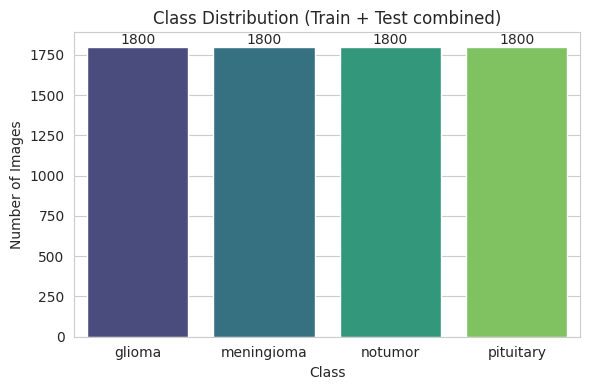

label
glioma        1800
meningioma    1800
notumor       1800
pituitary     1800
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=full_df, x="label", order=CLASS_NAMES, hue="label", palette="viridis", legend=False)
ax.set_title("Class Distribution (Train + Test combined)")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

print(full_df["label"].value_counts())


###### 4.2 Sample Images per Class

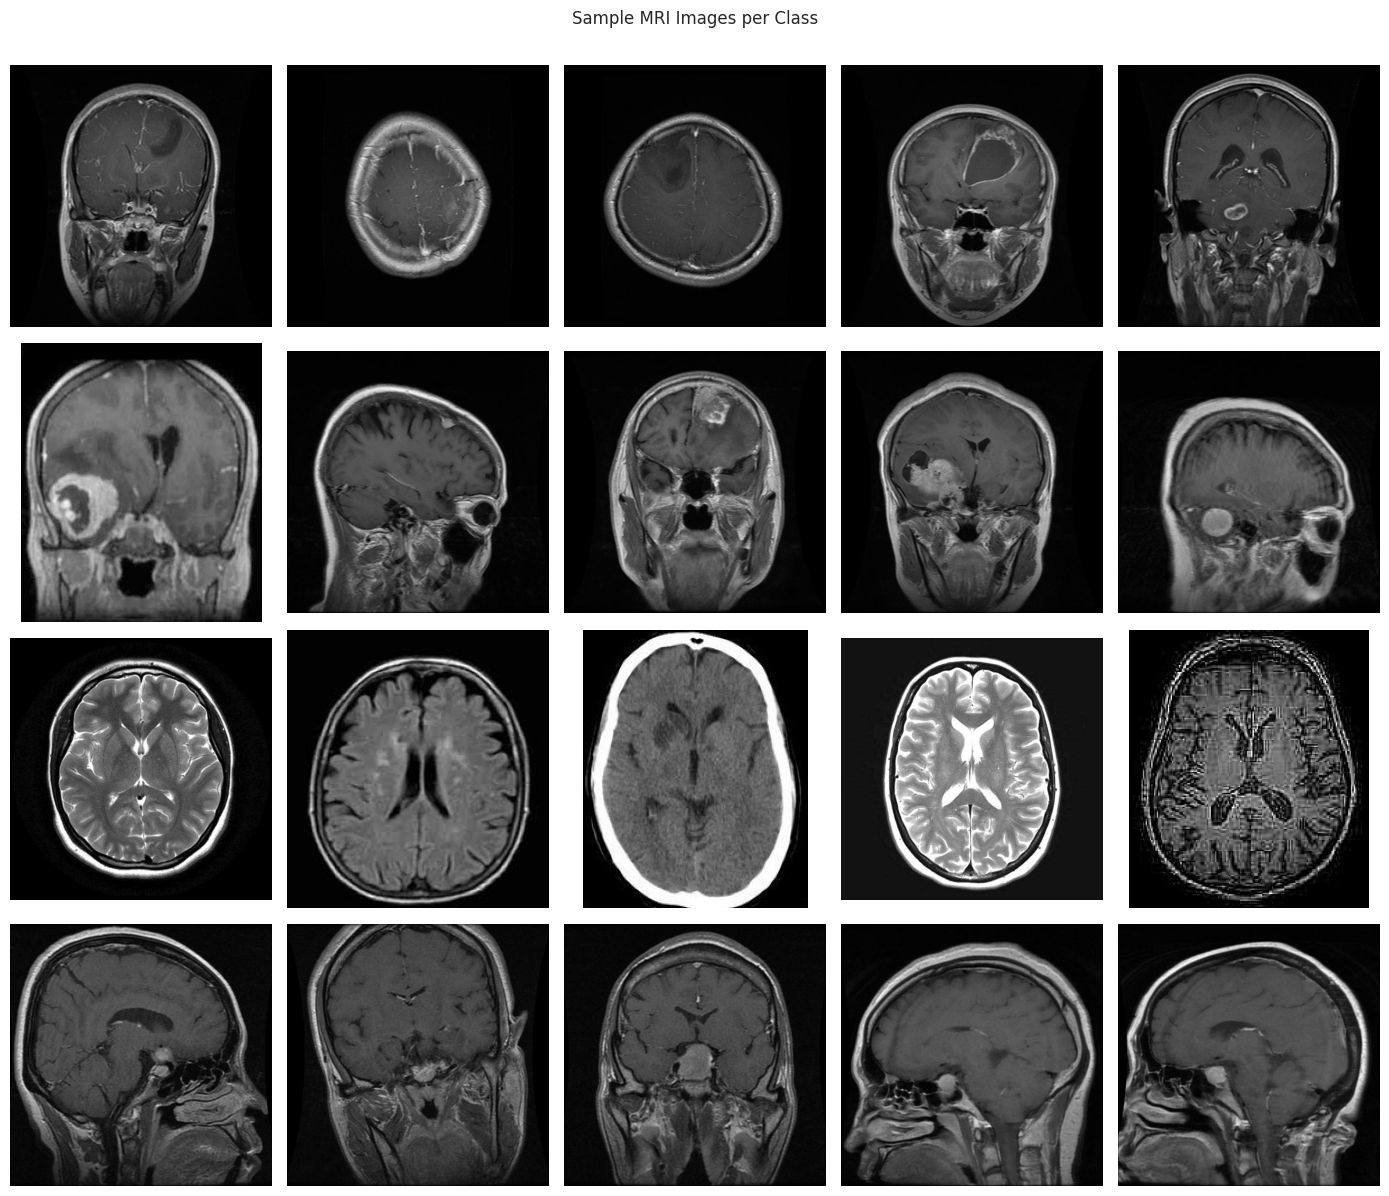

In [6]:
fig, axes = plt.subplots(len(CLASS_NAMES), 5, figsize=(14, 3 * len(CLASS_NAMES)))

for row, class_name in enumerate(CLASS_NAMES):
    class_samples = full_df[full_df["label"] == class_name].sample(5, random_state=SEED)
    for col, (_, sample_row) in enumerate(class_samples.iterrows()):
        img = cv2.imread(sample_row["image_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(class_name, fontsize=11)

plt.suptitle("Sample MRI Images per Class", y=1.0)
plt.tight_layout()
plt.show()


###### Corrupt Image Check

In [ ]:
corrupt_paths = []
for path in full_df["image_path"]:
    img = cv2.imread(path)
    if img is None:
        corrupt_paths.append(path)

print(f"Corrupt / unreadable images found: {len(corrupt_paths)}")
if len(corrupt_paths) > 0:
    full_df = full_df[~full_df["image_path"].isin(corrupt_paths)].reset_index(drop=True)
    print("Corrupt images are removed from dataframe")


Corrupt / unreadable images found: 0


##### Near-Duplicate Removal — Perceptual Hashing

In [ ]:
def compute_phash(path, hash_size=PHASH_SIZE):
    try:
        with Image.open(path) as im:
            return imagehash.phash(im.convert("L"), hash_size=hash_size)
    except Exception:
        return None


full_df["phash"] = full_df["image_path"].apply(compute_phash)
n_hash_fail = full_df["phash"].isna().sum()
if n_hash_fail:
    print(f"[WARNING] {n_hash_fail} images for which path not found are dropped")
    full_df = full_df.dropna(subset=["phash"]).reset_index(drop=True)
parent = {i: i for i in full_df.index}

def find(i):
    while parent[i] != i:
        parent[i] = parent[parent[i]]
        i = parent[i]
    return i

def union(i, j):
    ri, rj = find(i), find(j)
    if ri != rj:
        parent[rj] = ri

for class_name, group in full_df.groupby("label"):
    idxs = group.index.to_list()
    hashes = group["phash"].to_list()
    for a in range(len(idxs)):
        for b in range(a + 1, len(idxs)):
            if hashes[a] - hashes[b] <= PHASH_MAX_HAMMING:   # imagehash overrides '-' as Hamming distance
                union(idxs[a], idxs[b])

full_df["dup_cluster"] = full_df.index.map(find)

n_before = len(full_df)
n_clusters = full_df["dup_cluster"].nunique()
print(f"Images before near-duplicate removal : {n_before}")
print(f"Distinct visual clusters found       : {n_clusters}")
print(f"Near-duplicate images to be dropped  : {n_before - n_clusters}")

cluster_to_group = full_df.groupby("dup_cluster")["group_id"].first()
full_df["group_id"] = full_df["dup_cluster"].map(cluster_to_group)

full_df = full_df.drop_duplicates(subset="dup_cluster", keep="first").reset_index(drop=True)
full_df = full_df.drop(columns=["phash", "dup_cluster"])

print(f"Final unique images: {len(full_df)}")
print(f"Final distinct group_id count: {full_df['group_id'].nunique()}")


Images before near-duplicate removal : 7200
Distinct visual clusters found       : 4784
Near-duplicate images to be dropped  : 2416
Final unique images: 4784
Final distinct group_id count: 4028


##### Patient-Grouped Stratified Split (70 : 15 : 15)

In [ ]:
def stratified_group_split_20fold(df, label_col="label", group_col="group_id", seed=SEED):
    skf = StratifiedGroupKFold(n_splits=N_GROUP_FOLDS, shuffle=True, random_state=seed)

    fold_id = np.full(len(df), -1, dtype=int)
    for fold_num, (_, held_out_idx) in enumerate(
        skf.split(df, y=df[label_col], groups=df[group_col])
    ):
        fold_id[held_out_idx] = fold_num

    assert (fold_id >= 0).all(), "fold can not be assigned for some rows - StratifiedGroupKFold issue."

    train_mask = fold_id < TRAIN_FOLDS
    val_mask   = (fold_id >= TRAIN_FOLDS) & (fold_id < TRAIN_FOLDS + VAL_FOLDS)
    test_mask  = fold_id >= (TRAIN_FOLDS + VAL_FOLDS)

    return (
        df[train_mask].reset_index(drop=True),
        df[val_mask].reset_index(drop=True),
        df[test_mask].reset_index(drop=True),
    )


train_df, val_df, test_df = stratified_group_split_20fold(full_df)

print(f"Train: {len(train_df):5d}  ({len(train_df)/len(full_df):.1%})  groups={train_df['group_id'].nunique()}")
print(f"Val  : {len(val_df):5d}  ({len(val_df)/len(full_df):.1%})  groups={val_df['group_id'].nunique()}")
print(f"Test : {len(test_df):5d}  ({len(test_df)/len(full_df):.1%})  groups={test_df['group_id'].nunique()}")

balance_check = pd.concat([
    train_df["label"].value_counts(normalize=True).rename("train"),
    val_df["label"].value_counts(normalize=True).rename("val"),
    test_df["label"].value_counts(normalize=True).rename("test"),
], axis=1).round(3)
print("\nPer-class proportion by split (should be roughly similar across columns):")
print(balance_check)

# ---- HARD leakage assertions: no image path AND no group_id may appear in more than one split ----
train_paths, val_paths, test_paths = set(train_df["image_path"]), set(val_df["image_path"]), set(test_df["image_path"])
train_groups, val_groups, test_groups = set(train_df["group_id"]), set(val_df["group_id"]), set(test_df["group_id"])

assert len(train_paths & val_paths) == 0,  "Leakage: train/val have common image paths hain!"
assert len(train_paths & test_paths) == 0, "Leakage: train/test have common image paths hain!"
assert len(val_paths & test_paths) == 0,   "Leakage: val/test have common image paths hain!"

assert len(train_groups & val_groups) == 0,  "GROUP Leakage: train/val have same id!"
assert len(train_groups & test_groups) == 0, "GROUP Leakage: train/test have same id!"
assert len(val_groups & test_groups) == 0,   "GROUP Leakage: val/test have same id!"

print("\nLeakage check passed: No data leackage")


Train:  3350  (70.0%)  groups=2818
Val  :   717  (15.0%)  groups=604
Test :   717  (15.0%)  groups=606

Per-class proportion by split (should be roughly similar across columns):
            train    val   test
label                          
glioma      0.308  0.308  0.310
meningioma  0.293  0.296  0.293
pituitary   0.277  0.276  0.279
notumor     0.121  0.120  0.119

Leakage check passed: teeno splits image-level AND group-level (patient-level) completely disjoint hain.


##### Offline Preprocessing Cache (Skull-Strip + CLAHE, once, to disk)

In [ ]:
def skull_strip(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = np.ones((5, 5), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return img_bgr

    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)

    if w * h < 0.05 * (img_bgr.shape[0] * img_bgr.shape[1]):
        return img_bgr

    return img_bgr[y:y + h, x:x + w]


def apply_clahe(img_bgr, clip_limit=2.0, tile_grid_size=(8, 8)):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_enhanced = clahe.apply(l_channel)
    lab_enhanced = cv2.merge((l_enhanced, a_channel, b_channel))
    return cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2BGR)


def preprocess_image_bgr(image_path, size=IMG_SIZE):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise ValueError(f"Image load can not be loaded: {image_path}")
    stripped = skull_strip(img_bgr)
    enhanced = apply_clahe(stripped)
    resized = cv2.resize(enhanced, (size, size), interpolation=cv2.INTER_AREA)
    return resized


def cache_split(df, split_name, cache_root=CACHE_DIR):
    cached_rows = []
    for i, row in df.reset_index(drop=True).iterrows():
        label = row["label"]
        out_dir = os.path.join(cache_root, split_name, label)
        os.makedirs(out_dir, exist_ok=True)

        out_name = f"{row['group_id']}_{i}.png"      
        out_path = os.path.join(out_dir, out_name)

        if not os.path.exists(out_path):                 
            processed_bgr = preprocess_image_bgr(row["image_path"])
            cv2.imwrite(out_path, processed_bgr)

        new_row = row.to_dict()
        new_row["image_path"] = out_path
        cached_rows.append(new_row)

    return pd.DataFrame(cached_rows)


print("Caching train split (skull-strip + CLAHE, one-time)...")
train_df = cache_split(train_df, "train")
print("Caching val split...")
val_df = cache_split(val_df, "val")
print("Caching test split...")
test_df = cache_split(test_df, "test")

print("\nCaching done. Cached counts:")
print(f"Train: {len(train_df)}   Val: {len(val_df)}   Test: {len(test_df)}")
print(f"Cache directory: {CACHE_DIR}")


Caching train split (skull-strip + CLAHE, one-time)...
Caching val split...
Caching test split...

Caching done. Cached counts:
Train: 3350   Val: 717   Test: 717
Cache directory: /kaggle/working/preprocessed_cache


###### Cache Sanity Check

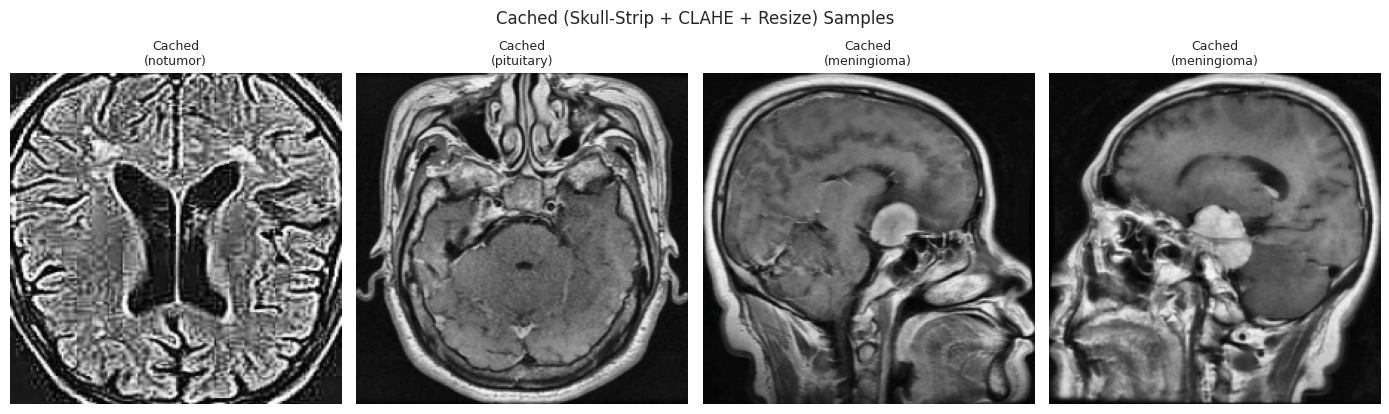

In [11]:
sample_check = train_df.sample(4, random_state=SEED)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i, (_, row) in enumerate(sample_check.iterrows()):
    cached = cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB)
    axes[i].imshow(cached)
    axes[i].set_title(f"Cached\n({row['label']})", fontsize=9)
    axes[i].axis("off")

plt.suptitle("Cached (Skull-Strip + CLAHE + Resize) Samples", y=1.03)
plt.tight_layout()
plt.show()


##### Medical-Safe Data Augmentation (sirf Train split par)

In [ ]:
train_augmentations = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(rotate_limit=15, scale_limit=0.1, shift_limit=0.05, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.CoarseDropout(max_holes=8, max_height=IMG_SIZE // 12, max_width=IMG_SIZE // 12, fill_value=0, p=0.3),
])

def _apply_train_augmentation(image_uint8):
    return train_augmentations(image=image_uint8)["image"]


##### Pipeline

In [ ]:
BATCH_SIZE = 32
EPOCHS     = 25
AUTOTUNE = tf.data.AUTOTUNE

def _load_and_decode(path):
    raw = tf.io.read_file(path)
    img = tf.io.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.uint8)  
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], method="area")
    img = tf.cast(img, tf.uint8)
    return img

def _make_map_fn(preprocess_fn, is_train):
    def _map_fn(path, label):
        img = _load_and_decode(path)
        if is_train:
            img = tf.numpy_function(func=_apply_train_augmentation, inp=[img], Tout=tf.uint8)
            img.set_shape([IMG_SIZE, IMG_SIZE, 3])
        img = tf.cast(img, tf.float32)
        img = preprocess_fn(img)                      # model-specific ImageNet normalization
        label = tf.one_hot(label, depth=len(CLASS_NAMES))
        return img, label
    return _map_fn

def build_tf_dataset(df, is_train, preprocess_fn, batch_size=BATCH_SIZE):
    paths = df["image_path"].values
    labels = df["class_id"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if is_train:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(_make_map_fn(preprocess_fn, is_train=True), num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(_make_map_fn(preprocess_fn, is_train=False), num_parallel_calls=AUTOTUNE, deterministic=True)

    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds
print("Dataset builder ready. Val/Test datasets are strictly ordered + unshuffled for safe evaluation.")


Dataset builder ready. Val/Test datasets are strictly ordered + unshuffled for safe evaluation.


##### Reusable Model Build, Train & Evaluation Functions

In [ ]:
def build_transfer_model(base_model_fn, model_name):
    base_model = base_model_fn(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    base_model.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(len(CLASS_NAMES), activation="softmax", name="predictions")(x)

    model = models.Model(inputs, outputs, name=model_name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def get_callbacks(model_name):
    return [
        callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        callbacks.ModelCheckpoint(f"{model_name}_best.keras", monitor="val_accuracy", save_best_only=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
    ]

def get_predictions(model, dataset, df):
    y_pred_probs = model.predict(dataset, verbose=0)          
    y_true_ids = df["class_id"].values[: len(y_pred_probs)]    
    y_pred_ids = np.argmax(y_pred_probs, axis=1)
    return y_true_ids, y_pred_ids, y_pred_probs


def compute_split_metrics(y_true_ids, y_pred_ids, split_name):
    return {
        "split": split_name,
        "accuracy": accuracy_score(y_true_ids, y_pred_ids),
        "precision": precision_score(y_true_ids, y_pred_ids, average="macro", zero_division=0),
        "recall": recall_score(y_true_ids, y_pred_ids, average="macro", zero_division=0),
        "f1": f1_score(y_true_ids, y_pred_ids, average="macro", zero_division=0),
    }


def full_evaluation(model, model_name, train_ds, test_ds, train_df_ref, test_df_ref):
    y_true_tr, y_pred_tr, _ = get_predictions(model, train_ds, train_df_ref)
    train_metrics = compute_split_metrics(y_true_tr, y_pred_tr, "train")

    y_true_te, y_pred_te, y_prob_te = get_predictions(model, test_ds, test_df_ref)
    test_metrics = compute_split_metrics(y_true_te, y_pred_te, "test")

    print(f"\n===== {model_name} - Train Metrics =====")
    for k, v in train_metrics.items():
        if k != "split":
            print(f"{k:>10}: {v:.4f}")

    print(f"\n===== {model_name} - Test Metrics =====")
    for k, v in test_metrics.items():
        if k != "split":
            print(f"{k:>10}: {v:.4f}")

    print(f"\n===== {model_name} - Test Classification Report =====")
    print(classification_report(y_true_te, y_pred_te, target_names=CLASS_NAMES, zero_division=0))

    cm = confusion_matrix(y_true_te, y_pred_te)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"{model_name} - Confusion Matrix (Test)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    y_true_bin = label_binarize(y_true_te, classes=list(range(len(CLASS_NAMES))))
    roc_auc = roc_auc_score(y_true_bin, y_prob_te, average="macro", multi_class="ovr")
    print(f"\n{model_name} - Test ROC-AUC (macro, OvR): {roc_auc:.4f}")

    plt.figure(figsize=(6, 5))
    for i, class_name in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob_te[:, i])
        auc_i = roc_auc_score(y_true_bin[:, i], y_prob_te[:, i])
        plt.plot(fpr, tpr, label=f"{class_name} (AUC={auc_i:.3f})")
    plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curve (Test, One-vs-Rest)")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    test_metrics["roc_auc"] = roc_auc
    return train_metrics, test_metrics


def plot_training_curves(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["accuracy"], label="Train")
    axes[0].plot(history.history["val_accuracy"], label="Val")
    axes[0].set_title(f"{model_name} - Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history.history["loss"], label="Train")
    axes[1].plot(history.history["val_loss"], label="Val")
    axes[1].set_title(f"{model_name} - Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


all_results = {}
print("Helper functions ready.")


Helper functions ready.


##### Model 1 — VGG16 + CNN Head

In [15]:
vgg16_train_ds = build_tf_dataset(train_df, is_train=True,  preprocess_fn=vgg16_preprocess)
vgg16_val_ds   = build_tf_dataset(val_df,   is_train=False, preprocess_fn=vgg16_preprocess)
vgg16_test_ds  = build_tf_dataset(test_df,  is_train=False, preprocess_fn=vgg16_preprocess)

vgg16_model = build_transfer_model(VGG16, "VGG16_CNN")
vgg16_model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 7, 7, 128)      │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,322,180 (58.45 MB)

 Trainable params: 607,236 (2.32 MB)

 Non-trainable params: 14,714,944 (56.13 MB)

Epoch 1/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 34s 212ms/step - accuracy: 0.6916 - loss: 0.9018 - val_accuracy: 0.7838 - val_loss: 0.5952 - learning_rate: 1.0000e-04
Epoch 2/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.8218 - loss: 0.5494 - val_accuracy: 0.8410 - val_loss: 0.4475 - learning_rate: 1.0000e-04
Epoch 3/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.8415 - loss: 0.4725 - val_accuracy: 0.8508 - val_loss: 0.4022 - learning_rate: 1.0000e-04
Epoch 4/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - accuracy: 0.8588 - loss: 0.4222 - val_accuracy: 0.8661 - val_loss: 0.3737 - learning_rate: 1.0000e-04
Epoch 5/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - accuracy: 0.8660 - loss: 0.3837 - val_accuracy: 0.8675 - val_loss: 0.3524 - learning_rate: 1.0000e-04
Epoch 6/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.8818 - loss: 0.3456 - val_accuracy: 0.8717 - val_loss: 0.3377 - learning_rate: 1.0000e-04
Epoch 7/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - a

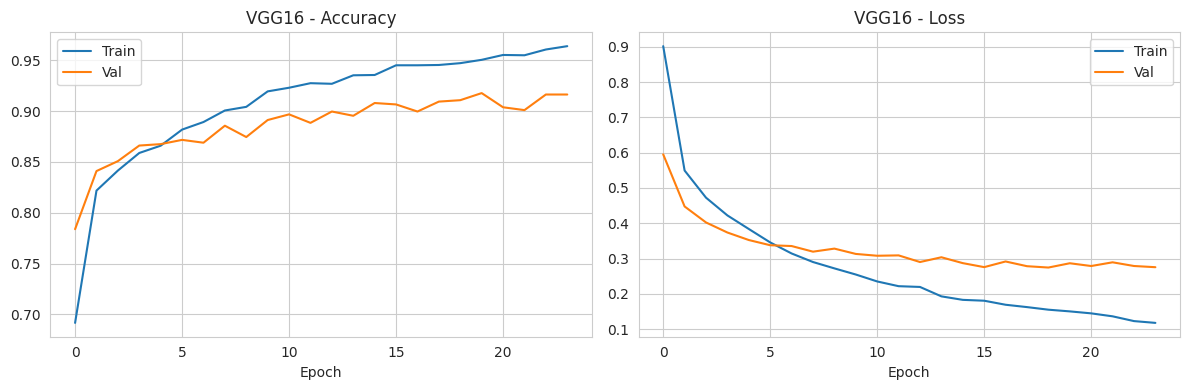

In [ ]:
vgg16_history = vgg16_model.fit(vgg16_train_ds, validation_data=vgg16_val_ds, epochs=EPOCHS, callbacks=get_callbacks("vgg16"),verbose=1,)
plot_training_curves(vgg16_history, "VGG16")

##### VGG16+CNN — Evaluation


===== VGG16 - Train Metrics =====
  accuracy: 0.2818
 precision: 0.2566
    recall: 0.2567
        f1: 0.2567

===== VGG16 - Test Metrics =====
  accuracy: 0.9303
 precision: 0.9280
    recall: 0.9294
        f1: 0.9284

===== VGG16 - Test Classification Report =====
              precision    recall  f1-score   support

      glioma       0.94      0.90      0.92       222
  meningioma       0.89      0.93      0.91       210
     notumor       0.91      0.92      0.91        85
   pituitary       0.98      0.97      0.98       200

    accuracy                           0.93       717
   macro avg       0.93      0.93      0.93       717
weighted avg       0.93      0.93      0.93       717



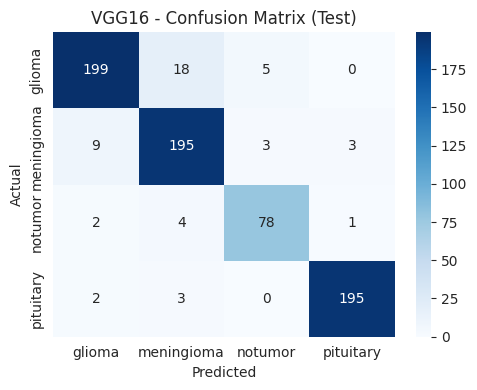


VGG16 - Test ROC-AUC (macro, OvR): 0.9880


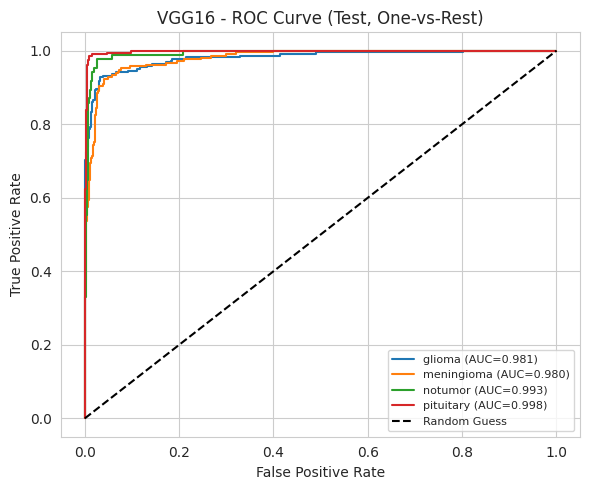

In [ ]:
vgg16_train_metrics, vgg16_test_metrics = full_evaluation(vgg16_model, "VGG16", vgg16_train_ds, vgg16_test_ds, train_df, test_df,)
all_results["VGG16"] = vgg16_test_metrics

##### 2 Model — ResNet50 + CNN Head

In [18]:
resnet50_train_ds = build_tf_dataset(train_df, is_train=True,  preprocess_fn=resnet50_preprocess)
resnet50_val_ds   = build_tf_dataset(val_df,   is_train=False, preprocess_fn=resnet50_preprocess)
resnet50_test_ds  = build_tf_dataset(test_df,  is_train=False, preprocess_fn=resnet50_preprocess)

resnet50_model = build_transfer_model(ResNet50, "ResNet50_CNN")
resnet50_model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "ResNet50_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,964,676 (99.05 MB)

 Trainable params: 2,376,708 (9.07 MB)

 Non-trainable params: 23,587,968 (89.98 MB)

##### ResNet50 + CNN Evalution

Epoch 1/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 41s 240ms/step - accuracy: 0.7391 - loss: 0.7144 - val_accuracy: 0.8243 - val_loss: 0.4829 - learning_rate: 1.0000e-04
Epoch 2/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.8543 - loss: 0.4457 - val_accuracy: 0.8536 - val_loss: 0.3968 - learning_rate: 1.0000e-04
Epoch 3/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - accuracy: 0.8716 - loss: 0.3620 - val_accuracy: 0.8689 - val_loss: 0.3684 - learning_rate: 1.0000e-04
Epoch 4/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - accuracy: 0.8890 - loss: 0.3224 - val_accuracy: 0.8661 - val_loss: 0.3648 - learning_rate: 1.0000e-04
Epoch 5/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - accuracy: 0.8976 - loss: 0.2946 - val_accuracy: 0.8801 - val_loss: 0.3508 - learning_rate: 1.0000e-04
Epoch 6/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.9119 - loss: 0.2548 - val_accuracy: 0.9093 - val_loss: 0.3053 - learning_rate: 1.0000e-04
Epoch 7/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step - a

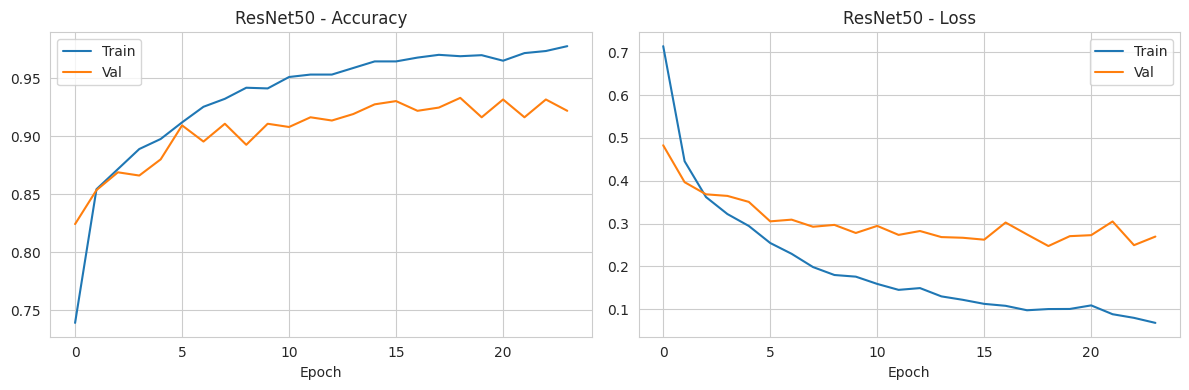

In [ ]:
resnet50_history = resnet50_model.fit(resnet50_train_ds, validation_data=resnet50_val_ds, epochs=EPOCHS, callbacks=get_callbacks("resnet50"), verbose=1,)
plot_training_curves(resnet50_history, "ResNet50")

###### 12.1 ResNet50 — Evaluation


===== ResNet50 - Train Metrics =====
  accuracy: 0.2803
 precision: 0.2547
    recall: 0.2546
        f1: 0.2546

===== ResNet50 - Test Metrics =====
  accuracy: 0.9372
 precision: 0.9270
    recall: 0.9420
        f1: 0.9335

===== ResNet50 - Test Classification Report =====
              precision    recall  f1-score   support

      glioma       0.96      0.93      0.95       222
  meningioma       0.93      0.89      0.91       210
     notumor       0.86      0.96      0.91        85
   pituitary       0.96      0.98      0.97       200

    accuracy                           0.94       717
   macro avg       0.93      0.94      0.93       717
weighted avg       0.94      0.94      0.94       717



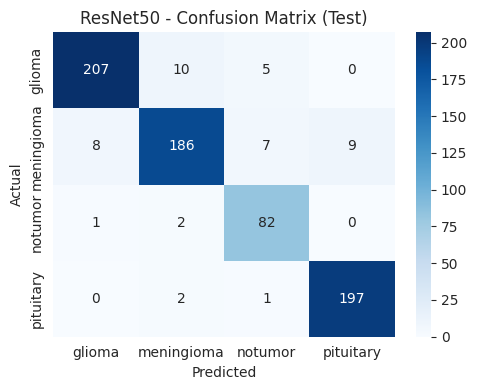


ResNet50 - Test ROC-AUC (macro, OvR): 0.9907


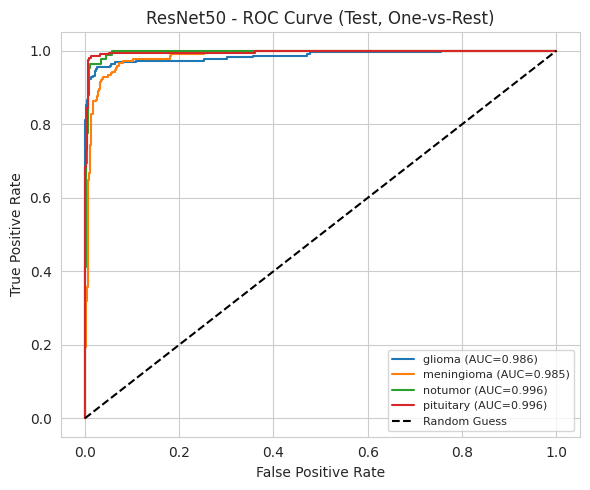

In [ ]:
resnet50_train_metrics, resnet50_test_metrics = full_evaluation(resnet50_model, "ResNet50", resnet50_train_ds, resnet50_test_ds, train_df, test_df,)
all_results["ResNet50"] = resnet50_test_metrics

##### 3 Model — EfficientNetB0 + CNN Head

In [21]:
effnet_train_ds = build_tf_dataset(train_df, is_train=True,  preprocess_fn=effnet_preprocess)
effnet_val_ds   = build_tf_dataset(val_df,   is_train=False, preprocess_fn=effnet_preprocess)
effnet_test_ds  = build_tf_dataset(test_df,  is_train=False, preprocess_fn=effnet_preprocess)

effnet_model = build_transfer_model(EfficientNetB0, "EfficientNetB0_CNN")
effnet_model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │     1,474,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,541,799 (21.14 MB)

 Trainable params: 1,491,972 (5.69 MB)

 Non-trainable params: 4,049,827 (15.45 MB)

Epoch 1/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 75s 425ms/step - accuracy: 0.7149 - loss: 0.7570 - val_accuracy: 0.8229 - val_loss: 0.4940 - learning_rate: 1.0000e-04
Epoch 2/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.8290 - loss: 0.4941 - val_accuracy: 0.8536 - val_loss: 0.3990 - learning_rate: 1.0000e-04
Epoch 3/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.8472 - loss: 0.4268 - val_accuracy: 0.8619 - val_loss: 0.3677 - learning_rate: 1.0000e-04
Epoch 4/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.8600 - loss: 0.3821 - val_accuracy: 0.8703 - val_loss: 0.3301 - learning_rate: 1.0000e-04
Epoch 5/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.8699 - loss: 0.3507 - val_accuracy: 0.8842 - val_loss: 0.3034 - learning_rate: 1.0000e-04
Epoch 6/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.8943 - loss: 0.3016 - val_accuracy: 0.8968 - val_loss: 0.2796 - learning_rate: 1.0000e-04
Epoch 7/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - a

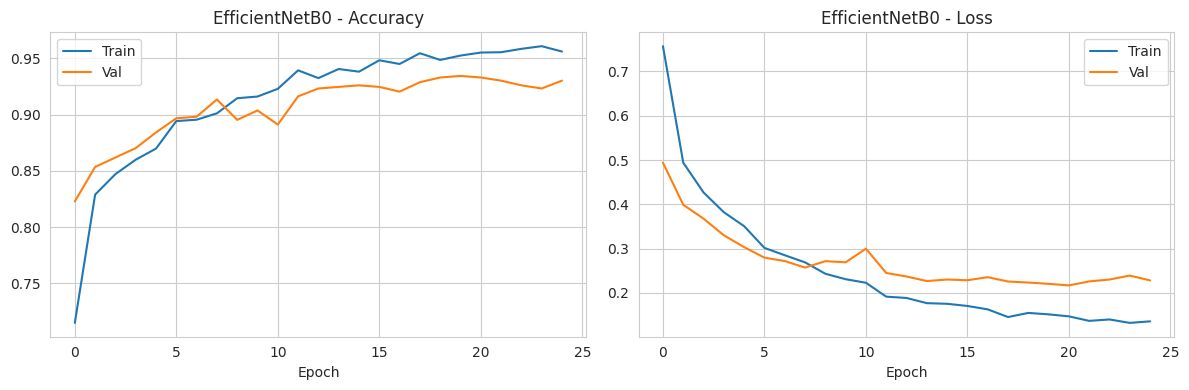

In [ ]:
effnet_history = effnet_model.fit(effnet_train_ds, validation_data=effnet_val_ds, epochs=EPOCHS, callbacks=get_callbacks("efficientnetb0"), verbose=1,)
plot_training_curves(effnet_history, "EfficientNetB0")


###### 13.1 EfficientNetB0 — Evaluation


===== EfficientNetB0 - Train Metrics =====
  accuracy: 0.2788
 precision: 0.2585
    recall: 0.2583
        f1: 0.2584

===== EfficientNetB0 - Test Metrics =====
  accuracy: 0.9470
 precision: 0.9426
    recall: 0.9506
        f1: 0.9462

===== EfficientNetB0 - Test Classification Report =====
              precision    recall  f1-score   support

      glioma       0.96      0.91      0.94       222
  meningioma       0.91      0.93      0.92       210
     notumor       0.91      0.96      0.94        85
   pituitary       0.99      0.99      0.99       200

    accuracy                           0.95       717
   macro avg       0.94      0.95      0.95       717
weighted avg       0.95      0.95      0.95       717



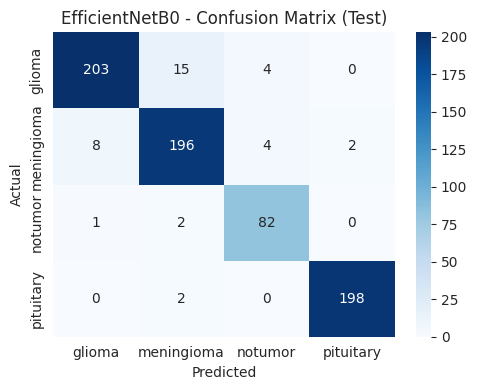


EfficientNetB0 - Test ROC-AUC (macro, OvR): 0.9923


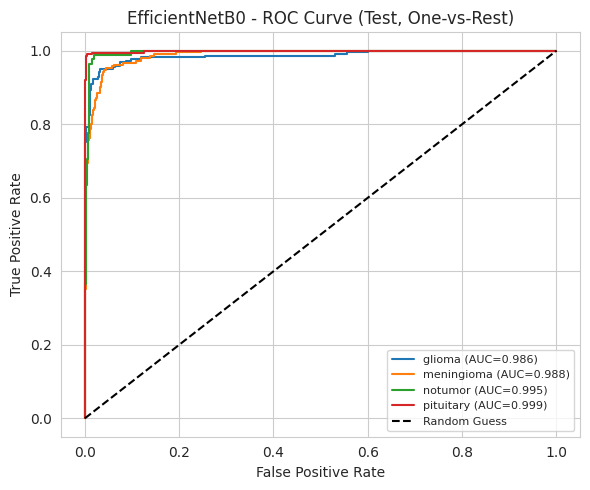

In [ ]:
effnet_train_metrics, effnet_test_metrics = full_evaluation(effnet_model, "EfficientNetB0", effnet_train_ds, effnet_test_ds, train_df, test_df,)
all_results["EfficientNetB0"] = effnet_test_metrics

##### Final Model Comparison (Test Set)

In [24]:
comparison_df = pd.DataFrame(all_results).T
comparison_df = comparison_df[["accuracy", "precision", "recall", "f1", "roc_auc"]]
comparison_df = comparison_df.round(4)
comparison_df


,accuracy,precision,recall,f1,roc_auc
VGG16,0.930265,0.92798,0.929404,0.928438,0.987991
ResNet50,0.937238,0.92695,0.941963,0.933519,0.990682
EfficientNetB0,0.947001,0.942572,0.950613,0.946245,0.992302


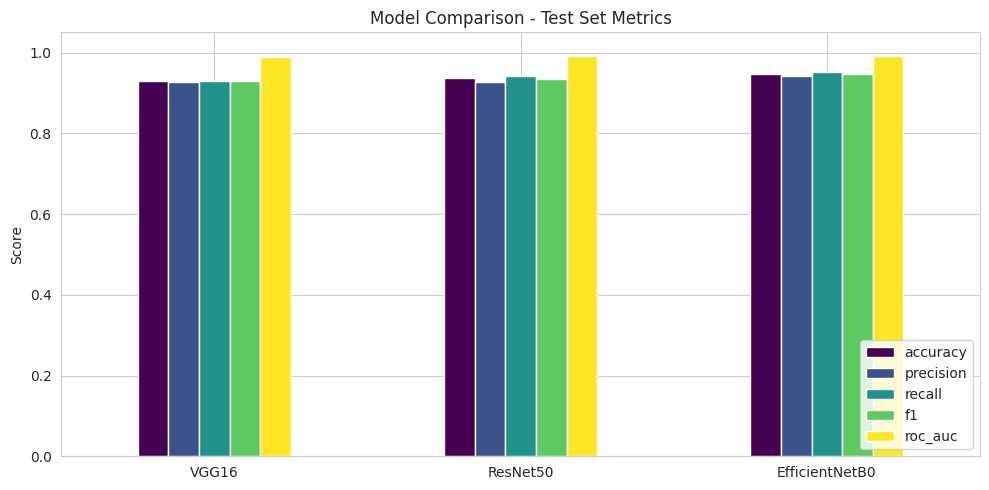

Best performing model (by Test F1-score): EfficientNetB0


In [25]:
comparison_df[["accuracy", "precision", "recall", "f1", "roc_auc"]].plot(
    kind="bar", figsize=(10, 5), colormap="viridis"
)
plt.title("Model Comparison - Test Set Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

best_model = comparison_df["f1"].idxmax()
print(f"Best performing model (by Test F1-score): {best_model}")
